# Pandas: Data Management 3

*Author: Evan Carey, written for BH Analytics*

## Overview

In this section, we will continue coverage of data management using Pandas. 

Our Objectives for this section are:

*  Sorting Dataframes
*  Random Sampling Dataframes
*  Deal with Missing Data
*  Merging Dataframes

## Data for this Session: Healthcare Visits

To demonstrate these concepts, we will use some simulated data from a health care system. There are two files we will use throughout this section. 

*  The first file is called `Patient.csv`, and is information about patients in the healthcare system. There should be one row per patient in this file, so we call this a patient level file. 

*  The second file is called `OutpatientVisit.csv`, and is information about individual visits to the doctor for patients in the healthcare system. There will be more than one row per patient in this file, since patients can have more than one visit. However, there should only be one row per visit, so we call this a visit-level file. 

The files are located here: 

* data/healthcare/Patient.csv
* data/healthcare/OutpatientVisit.csv

## Libraries

In [1]:
import sys
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import textwrap

In [2]:
# Enable inline plotting for graphics
%matplotlib inline

There are a few new packages here we are calling! 

* Pandas is the data management package that we will focus on. 
* Numpy is the numerical computation package in Python. You can think of this as part of the engine under the hood of Pandas...
* Matplotlib is the main plotting package in Python
* Seaborn is an 'add-on' plotting package that is based on Matplotlib. More details on these to come later!

In [3]:
# Get Version information
print(textwrap.fill(sys.version),'\n')
print("Pandas version: {0}".format(pd.__version__),'\n')
print("Matplotlib version: {0}".format(matplotlib.__version__),'\n')
print("Numpy version: {0}".format(np.__version__),'\n')
print("Seaborn version: {0}".format(sns.__version__),'\n')

3.7.10 (default, Feb 26 2021, 13:06:18) [MSC v.1916 64 bit (AMD64)] 

Pandas version: 1.2.4 

Matplotlib version: 3.3.4 

Numpy version: 1.20.1 

Seaborn version: 0.11.1 



In [4]:
# So all output comes through from Ipython
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Set options

Here I set the max printing rows to be 10, so I don't overwhelm the printed workbooks or these presentation materials. You can change this to a larger number since you are running this on your own machine. 

In [5]:
pd.options.display.max_rows = 10

## Check your working directory

Subsequent sessions may require you to identify and update your working directory so paths correctly point at the downloaded data files. You can check your working directory like so:

In [6]:
# Working Directory
print(os.getcwd())

C:\Users\evancarey\Dropbox\Work\BHAnalytics\courseware\Python_Courses\course_downloads\CDC_Python_Week1\notebooks


You can simply assign the working directory to be 'one level above the current directory' by running this line of code with the `..` as the path. 
  
`..` means 'one directory above the current directory.
  
Note you should only run it once! If you run it multiple times, you will keep reseting the working directory to one level above the current directory, until you reach the root of the drive!

In [7]:
# Set Working Directory (if needed)
# you can just do this:
os.chdir(r"..") 

For the purpose of compiling these notebooks, I put my working directory here, but this line of code will give you an error since this location does not exist on your file system! I have included the `try` command to avoid the error preventing the rest of the notebook from running in case you miss this.

You could update this string: `r"C:\Users\evancarey\Dropbox\Work"`  

to be a valid path on your filesystem pointing at the course download. 

In [8]:
# Set New Working Directory 
# the try except tells Python to try to run the code
# and if an error occurs, print a message
try:
    os.chdir(r"C:\Users\evancarey\Dropbox\Work")
except:
    print("ERROR: You probably forgot to change the directory path!")

In [9]:
# Confirm it changed the working Directory
print("My working directory:\n" + os.getcwd())

My working directory:
C:\Users\evancarey\Dropbox\Work


## Importing structured data

We will start by importing the patient data. If we were importing these from CSV, we would check both of these files using a text editor first:

* Do they have column names in the first row?
* What is the delimiter? Is it actually a CSV?
* How many rows and columns does the file have? 

Here, we are using the pickle file we made in the previous module, which means we can load the object and preserve its data types and structure using the `read_pickle()` method.

In [10]:
## import data
## By using our pickle from the previous workbook, we can restore the appropriate data types!
df_patient = \
    pd.read_pickle("Data/Data_Sims/healthcare/Patient_cleaned.pkl")


Following import, you can examine the top and bottom of the dataframe simply by calling the object:

In [11]:
df_patient

,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
0,1,Loretta,Gunter,FL,32250,1979-03-29,female,white,29.0,white,1979-03-29,Low
1,2,Todd,Rea,TX,79602,1936-12-20,male,Missing,NaN,NaN,1936-12-20,NaN
2,3,Margaret,Goodwin,PA,18106,1948-04-19,female,hispanic,53.0,hispanic,1948-04-19,Medium
3,4,Anna,McCullough,TX,75039,1997-08-28,female,Missing,20.0,NaN,1997-08-28,Low
4,5,Glenn,Labrecque,NM,87102,1985-08-19,male,Missing,48.0,NaN,1985-08-19,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,Lucia,Atkins,MI,49546,1970-01-26,female,white,166.0,white,1970-01-26,High
19996,19997,Wilfredo,Reinhardt,CO,80112,1950-02-23,male,other,31.0,other,1950-02-23,Low
19997,19998,Thanh,Large,FL,33912,1957-11-24,male,black,60.0,black,1957-11-24,Medium
19998,19999,Deidre,Croft,GA,30303,1965-01-24,female,Unknown,NaN,NaN,1965-01-24,NaN


In [12]:
df_patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   PatientID       20000 non-null  object        
 1   FirstName       20000 non-null  object        
 2   LastName        20000 non-null  object        
 3   State           20000 non-null  object        
 4   ZipCode         20000 non-null  int64         
 5   DateOfBirth     19060 non-null  object        
 6   Gender          19426 non-null  object        
 7   Race            19254 non-null  object        
 8   Income          18600 non-null  float64       
 9   Race_cat        14397 non-null  category      
 10  DateOfBirth_dt  19060 non-null  datetime64[ns]
 11  Income_Cat      17858 non-null  category      
dtypes: category(2), datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 1.6+ MB


## Reindexing Dataframes

We often take a subset of a dataframe, and we may need to reindex the rows afterwards.   
This is not done automatically post-subset!

In [13]:
# Reindex
df_patient_sub = \
    df_patient[df_patient['Income'] > 500]
df_patient_sub

,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
8,9,William,Fontenot,OH,45402,1938-04-24,male,,1093.0,NaN,1938-04-24,NaN
60,61,Tara,Anderson,AL,36303,1879-10-30,female,white,1138.0,white,1879-10-30,NaN
61,62,Diego,Yang,PA,18621,1956-11-24,male,NaN,1093.0,NaN,1956-11-24,NaN
72,73,Lauren,Sturdevant,UT,84104,1997-04-18,female,Missing,1131.0,NaN,1997-04-18,NaN
99,100,Amanda,Delgado,KS,67107,1976-11-05,female,,1079.0,NaN,1976-11-05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
19889,19890,Adam,Carr,LA,71101,1998-01-13,male,white,1013.0,white,1998-01-13,NaN
19900,19901,James,Thurman,OH,43950,1958-10-18,male,other,1063.0,other,1958-10-18,NaN
19937,19938,Curtis,Owens,CT,6492,1979-04-03,male,white,1108.0,white,1979-04-03,NaN
19952,19953,Olive,Hansen,IL,60191,1960-06-28,female,white,1023.0,white,1960-06-28,NaN


We then reset the index with `reset_index()` method. 

In [14]:
df_patient_sub = \
    df_patient_sub.reset_index()
df_patient_sub.head()

,index,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
0,8,9,William,Fontenot,OH,45402,1938-04-24,male,,1093.0,NaN,1938-04-24,NaN
1,60,61,Tara,Anderson,AL,36303,1879-10-30,female,white,1138.0,white,1879-10-30,NaN
2,61,62,Diego,Yang,PA,18621,1956-11-24,male,NaN,1093.0,NaN,1956-11-24,NaN
3,72,73,Lauren,Sturdevant,UT,84104,1997-04-18,female,Missing,1131.0,NaN,1997-04-18,NaN
4,99,100,Amanda,Delgado,KS,67107,1976-11-05,female,,1079.0,NaN,1976-11-05,NaN


In [15]:
del df_patient_sub["index"]
df_patient_sub.head()

,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
0,9,William,Fontenot,OH,45402,1938-04-24,male,,1093.0,NaN,1938-04-24,NaN
1,61,Tara,Anderson,AL,36303,1879-10-30,female,white,1138.0,white,1879-10-30,NaN
2,62,Diego,Yang,PA,18621,1956-11-24,male,NaN,1093.0,NaN,1956-11-24,NaN
3,73,Lauren,Sturdevant,UT,84104,1997-04-18,female,Missing,1131.0,NaN,1997-04-18,NaN
4,100,Amanda,Delgado,KS,67107,1976-11-05,female,,1079.0,NaN,1976-11-05,NaN


Notice the extra column of the index was added by default. We can get rid of that with `drop=True`. 

In [16]:
# Alternatively, all in one line of code
df_patient_sub = \
    df_patient_sub.reset_index(drop=True)
df_patient_sub.head()

,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
0,9,William,Fontenot,OH,45402,1938-04-24,male,,1093.0,NaN,1938-04-24,NaN
1,61,Tara,Anderson,AL,36303,1879-10-30,female,white,1138.0,white,1879-10-30,NaN
2,62,Diego,Yang,PA,18621,1956-11-24,male,NaN,1093.0,NaN,1956-11-24,NaN
3,73,Lauren,Sturdevant,UT,84104,1997-04-18,female,Missing,1131.0,NaN,1997-04-18,NaN
4,100,Amanda,Delgado,KS,67107,1976-11-05,female,,1079.0,NaN,1976-11-05,NaN


## Sorting a Dataframe

We use `.sort_values()` to sort a data frame.

We can sort by either the index or a column(s)

In [17]:
# Sorting
df_patient\
    .sort_values("Income")\
    .head()

,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
12225,12226,Emily,Locher,MO,63362,1966-08-12,MISSING,white,3.0,white,1966-08-12,Low
188,189,Mary,James,CT,6902,1985-04-04,MISSING,white,3.0,white,1985-04-04,Low
10879,10880,Dean,Ragland,PA,19123,1960-02-28,male,Missing,3.0,NaN,1960-02-28,Low
6649,6650,Barbara,O'Donnell,MS,38901,1845-03-07,female,Unknown,4.0,NaN,1845-03-07,Low
12437,12438,Billy,Dickson,PA,19403,1939-07-26,male,hispanic,4.0,hispanic,1939-07-26,Low


In [18]:
# Sort by ascending
df_patient\
    .sort_values("Income", ascending=False)\
    .head()

,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
16454,16455,Judy,Hasbrouck,IL,60089,1940-05-18,female,white,1780.0,white,1940-05-18,NaN
245,246,Charlie,Hilliard,NJ,8102,1970-05-06,male,hispanic,1613.0,hispanic,1970-05-06,NaN
4945,4946,Jerry,Bell,MD,21201,1977-04-22,male,black,1462.0,black,1977-04-22,NaN
13729,13730,Charles,Strayhorn,IL,60653,1845-03-02,NaN,,1412.0,NaN,1845-03-02,NaN
11407,11408,James,Eckert,SC,29601,1988-08-22,male,Missing,1412.0,NaN,1988-08-22,NaN


In [19]:
# Multiple sorts
df_patient\
    .sort_values(by=["Gender","Income"])\
    .head()

,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
188,189,Mary,James,CT,6902,1985-04-04,MISSING,white,3.0,white,1985-04-04,Low
12225,12226,Emily,Locher,MO,63362,1966-08-12,MISSING,white,3.0,white,1966-08-12,Low
2226,2227,Eva,Berry,FL,32401,NaN,MISSING,other,4.0,other,NaT,Low
10544,10545,Kay,Kohr,MI,48864,1937-12-07,MISSING,other,6.0,other,1937-12-07,Low
13114,13115,Mark,Brown,MO,64060,1976-10-30,MISSING,Missing,6.0,NaN,1976-10-30,Low


In [20]:
# Mixture of descending and ascending sorts
df_patient\
    .sort_values(by=["Gender","Income"],
                 ascending=[True,False])

,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
1090,1091,Garry,Provost,CA,92020,1977-02-08,MISSING,white,1382.0,white,1977-02-08,NaN
8641,8642,Cedrick,Millan,CA,93240,1977-07-01,MISSING,black,1201.0,black,1977-07-01,NaN
18120,18121,India,Neal,CT,6702,1964-11-27,MISSING,hispanic,1194.0,hispanic,1964-11-27,NaN
1243,1244,Lorraine,Hughes,AK,99503,1960-01-02,MISSING,?,1150.0,NaN,1960-01-02,NaN
13540,13541,Sue,Bright,NJ,7305,1970-08-16,MISSING,white,1144.0,white,1970-08-16,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
18072,18073,Henry,Carmody,CO,80202,NaN,NaN,hispanic,NaN,hispanic,NaT,NaN
18900,18901,George,Golden,MS,39213,1969-03-30,NaN,white,NaN,white,1969-03-30,NaN
19128,19129,Jennifer,Beason,DC,20005,1943-04-12,NaN,black,NaN,black,1943-04-12,NaN
19642,19643,Eleanor,Ratcliff,NJ,7087,1983-02-21,NaN,white,NaN,white,1983-02-21,NaN


## Missing Data in Dataframes

Accounting for missing data is an important part of any analysis. You first need to be able to notice and quantify the missing data in your dataframe. After that, you should think carefully about why the data is missing, and what process led to it being missing.  

> Question: What happens to missing data if we ignore it in an analysis? For example, if you run a linear regression with missing data, what happens?

Missing data mechanics: 
* Missing data is represented as NaN in a dataframe. 
* Pandas can deal with missing data appropriately inside of functions. 


When you have missing data, you generally need to do the following things:

* Quantify the missingness. How much is missing in each column? 
* Flag the missing values so you can hopefully retrieve them by asking the source of your data to send you the missing elements. 
* Exclude the rows with missing elements from your analysis (if you must, this is one option)
* Impute missing data, like adding the mean of a numeric variable in place of the missingness. 

> Missing data imputation should not be taken lightly. Extensive coverage of this topic is out of scope for this lecture; but you should think more about this when it comes up in your practice. 

We will start with detecting missing data. We can detect missing data the `isnull()` method. You can then apply the `any()` and `sum()` methods to summarize missingness by column or row. 

In [21]:
# Checking for missing data
df_patient.isnull()

,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,True,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,True,True,False,True


In [22]:
# which columns have missing data
df_patient\
    .isnull()\
    .any(axis=0)

PatientID         False
FirstName         False
LastName          False
State             False
ZipCode           False
                  ...  
Race               True
Income             True
Race_cat           True
DateOfBirth_dt     True
Income_Cat         True
Length: 12, dtype: bool

In [23]:
# which rows have missing data
df_patient\
    .isnull()\
    .any(1)

0        False
1         True
2        False
3         True
4         True
         ...  
19995    False
19996    False
19997    False
19998     True
19999     True
Length: 20000, dtype: bool

In [24]:
# How many missing per column?
df_patient\
    .isnull()\
    .sum(0)

PatientID            0
FirstName            0
LastName             0
State                0
ZipCode              0
                  ... 
Race               746
Income            1400
Race_cat          5603
DateOfBirth_dt     940
Income_Cat        2142
Length: 12, dtype: int64

## Dropping Missing Data

We can drop any rows with missing data using `dropna()`.

Why would we need to do this?!? We are not able to do math on missing data. If we will eventually be fitting a multivariate model on this data, all the missing elements will be kicked out at that point. We may wish to consider what the data looks like up front with those elements missing, rather than wait until the end...



In [25]:
# Drop rows with missing data
df_patient\
    .dropna(axis=0)

,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
0,1,Loretta,Gunter,FL,32250,1979-03-29,female,white,29.0,white,1979-03-29,Low
2,3,Margaret,Goodwin,PA,18106,1948-04-19,female,hispanic,53.0,hispanic,1948-04-19,Medium
5,6,Marlo,Helms,AZ,85701,1953-03-20,female,white,54.0,white,1953-03-20,Medium
6,7,Timothy,Allison,CT,6450,1888-04-08,male,black,60.0,black,1888-04-08,Medium
7,8,Gina,McDonald,GA,30064,1984-11-27,female,white,101.0,white,1984-11-27,High
...,...,...,...,...,...,...,...,...,...,...,...,...
19993,19994,James,Devault,OH,44902,1986-09-06,male,black,33.0,black,1986-09-06,Low
19994,19995,Ronald,Henry,NJ,8060,1957-05-09,male,black,54.0,black,1957-05-09,Medium
19995,19996,Lucia,Atkins,MI,49546,1970-01-26,female,white,166.0,white,1970-01-26,High
19996,19997,Wilfredo,Reinhardt,CO,80112,1950-02-23,male,other,31.0,other,1950-02-23,Low


In [26]:
# drop columns with missing data
# less useful...
df_patient\
    .dropna(axis=1)\
    .head()

,PatientID,FirstName,LastName,State,ZipCode
0,1,Loretta,Gunter,FL,32250
1,2,Todd,Rea,TX,79602
2,3,Margaret,Goodwin,PA,18106
3,4,Anna,McCullough,TX,75039
4,5,Glenn,Labrecque,NM,87102


## Imputing the Missing Data Values

We can impute the missing data, replacing the NaN with the mean values. 

Categorical values correctly remain missing because there is no mean.

In [27]:
# Fill in missing values with mean
# This only fills in numeric values
df_patient_no_na = \
    df_patient.fillna(df_patient.mean(numeric_only=True))

In [28]:
# The categorical values remain
# How many missing per column?
df_patient_no_na\
    .isnull()\
    .sum(0)

PatientID            0
FirstName            0
LastName             0
State                0
ZipCode              0
                  ... 
Race               746
Income               0
Race_cat          5603
DateOfBirth_dt     940
Income_Cat        2142
Length: 12, dtype: int64

We could also impute these values with the last value carried forward, or other options (Check the help for fillna).

In [29]:
## Fill with last value carried forward
df_patient_no_na = \
    df_patient.fillna(method='ffill')

## Random Sampling from our Data

We may wish to randomly sample observations from our dataset. This is easy to do in pandas. We may either choose to sample a fraction of the data (10%), or an exact number (50 rows). 

In [30]:
df_patient\
    .sample(frac=.1,
            random_state=42)\
    .head()

,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
10650,10651,Larry,Copper,IN,46601,1995-07-14,male,white,1030.0,white,1995-07-14,NaN
2041,2042,Dale,Turner,IN,46307,1993-04-20,male,,10.0,NaN,1993-04-20,Low
8668,8669,Susan,Hoffman,AL,36205,1951-10-09,female,other,93.0,other,1951-10-09,High
1114,1115,Nicholas,Arellano,VA,22204,1850-01-14,male,hispanic,106.0,hispanic,1850-01-14,High
13902,13903,Ana,Tovar,MI,49254,1944-09-18,female,,28.0,NaN,1944-09-18,Low


In [31]:
df_patient\
    .sample(n=50,
            random_state=42)\
    .head()

,PatientID,FirstName,LastName,State,ZipCode,DateOfBirth,Gender,Race,Income,Race_cat,DateOfBirth_dt,Income_Cat
10650,10651,Larry,Copper,IN,46601,1995-07-14,male,white,1030.0,white,1995-07-14,NaN
2041,2042,Dale,Turner,IN,46307,1993-04-20,male,,10.0,NaN,1993-04-20,Low
8668,8669,Susan,Hoffman,AL,36205,1951-10-09,female,other,93.0,other,1951-10-09,High
1114,1115,Nicholas,Arellano,VA,22204,1850-01-14,male,hispanic,106.0,hispanic,1850-01-14,High
13902,13903,Ana,Tovar,MI,49254,1944-09-18,female,,28.0,NaN,1944-09-18,Low


## Merging Dataframes

The final topic for this data management section is how to merge our dataframes together. We express this in the typical SQL style merging terminology of inner, outer left, outer right, and full outer joins. We will use the OutpatientVisits file we imported earlier to demonstrate the syntax for various joins in a few moments. 

First, let's think about the role joins play in answering questions. Review the grahpic below, and think about the following for each question:

-  What information (columns) is required from each table to answer the question? 
-  Which rows are required from each table to answer the question? 

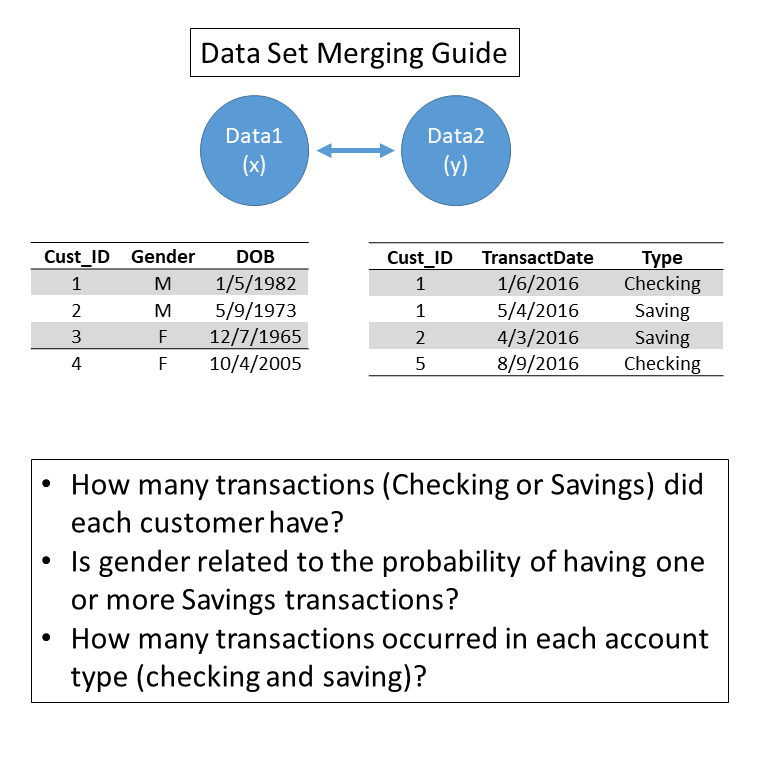

In [32]:
from IPython.display import Image
Image(filename='common/Merging_1.png')

Recall the SQL style syntax for merging tables together (summarized below). This is implemented in Pandas. 

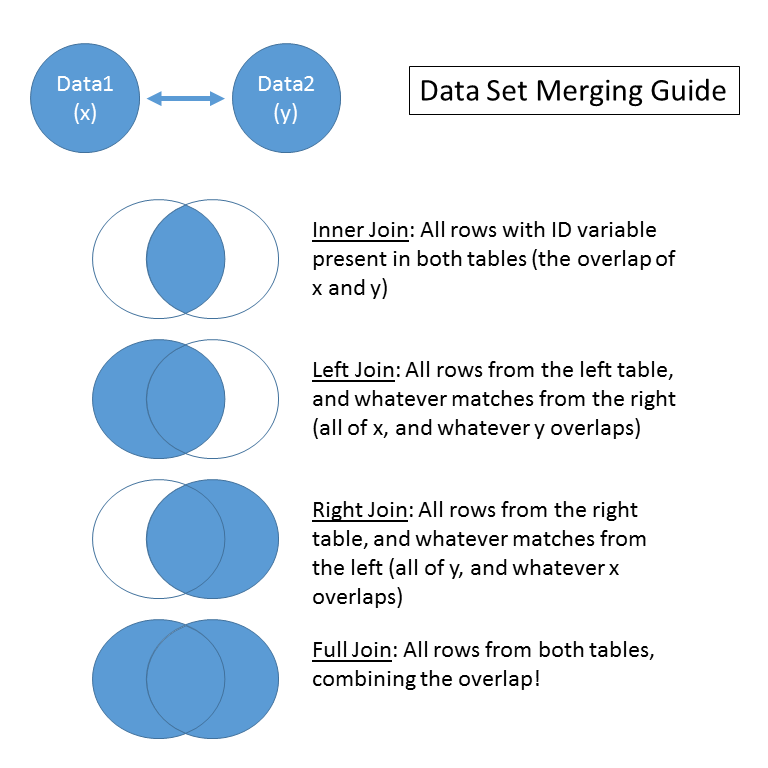

In [33]:
from IPython.display import Image
Image(filename='common/Merging_2.png')

Let's merge the outpatient data to the visits data. We want to kepp all the patients from the patient table, and whatever visits they had. 
  
Our first step should always be to check the merge column for unique and length. 

## What does merging do?

If you're not familiar with merging, it's helpful to see the process on a smaller dataset. 

Here, we will slice our data sets to make small examples that display nicely on screen.

In [34]:
# we select the first 4 rows of patien, and ID and Name only
x_dta = df_patient.loc[df_patient['PatientID']<5,"PatientID":"LastName"].reset_index(drop=True)
x_dta

,PatientID,FirstName,LastName
0,1,Loretta,Gunter
1,2,Todd,Rea
2,3,Margaret,Goodwin
3,4,Anna,McCullough


In [35]:
# we import and select a few rows and ID and visit date from visits
df_visits = \
    pd.read_csv("Data/Data_Sims/healthcare/OutpatientVisit.csv")
y_dta = df_visits.iloc[[2,18,19,50],[2,3]].reset_index(drop=True)
y_dta

,PatientID,VisitDate
0,1,2013-12-28
1,3,2013-01-04
2,3,2013-11-07
3,8,2014-07-17


In [36]:
## Merging Datasets
# check uniques pre-merge
x_dta['PatientID'].nunique()

4

In [37]:
y_dta['PatientID'].nunique() 

3

In [38]:
set(x_dta['PatientID']) # the unique IDs in patients
set(y_dta['PatientID']) # the unique IDs in visits
# Check the overlap?
print("intersection")
set(x_dta['PatientID']) & set(y_dta['PatientID'])

{1, 2, 3, 4}

{1, 3, 8}

intersection


{1, 3}

In [39]:
# Left outer join
left_merged_dta = \
    pd.merge(x_dta,
             y_dta,
             how='left',
             on='PatientID')
left_merged_dta.style.highlight_null(null_color='yellow')

,PatientID,FirstName,LastName,VisitDate
0,1,Loretta,Gunter,2013-12-28
1,2,Todd,Rea,nan
2,3,Margaret,Goodwin,2013-01-04
3,3,Margaret,Goodwin,2013-11-07
4,4,Anna,McCullough,nan


In [40]:
# Inner join
inner_merged_dta = \
    pd.merge(x_dta,
             y_dta,
             how='inner',
             on='PatientID')
inner_merged_dta.style.highlight_null(null_color='yellow')

,PatientID,FirstName,LastName,VisitDate
0,1,Loretta,Gunter,2013-12-28
1,3,Margaret,Goodwin,2013-01-04
2,3,Margaret,Goodwin,2013-11-07


In [41]:
# Full / outer join
outer_merged_dta = \
    pd.merge(x_dta,
             y_dta,
             how='outer',
             on='PatientID')
outer_merged_dta.style.highlight_null(null_color='yellow')

,PatientID,FirstName,LastName,VisitDate
0,1.000000,Loretta,Gunter,2013-12-28
1,2.000000,Todd,Rea,nan
2,3.000000,Margaret,Goodwin,2013-01-04
3,3.000000,Margaret,Goodwin,2013-11-07
4,4.000000,Anna,McCullough,nan
5,8.000000,nan,nan,2014-07-17


For more information, consult the Handbook's chapter on merges:   
https://jakevdp.github.io/PythonDataScienceHandbook/03.07-merge-and-join.html

## Review

In this section, we covered:

*  Sorting Dataframes
*  Random Sampling Dataframes
*  Deal with Missing Data
*  Merging Dataframes